Loading libraries

In [3]:
library(dplyr)
library(ggplot2)
library(gridExtra)
library(grid)
library(readr)
library(purrr)
library(tidyr)
library(zoo)
library(moments)

Loading tables

In [2]:



# Read the CSV file
table_2y <- read.csv("~/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/paper_resilience/tables_results/PLS_alive_traits_MAN_30prec_2y.csv") %>% # nolint
  mutate(Source = "2y")

table_8y <- read.csv("~/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/paper_resilience/tables_results/PLS_alive_traits_MAN_30prec_8y.csv") %>% # nolint
  mutate(Source = "8y")

table_regclim <- read.csv("~/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/paper_resilience/tables_results/PLS_alive_traits_MAN_regularclimate.csv") %>% #nolint
  mutate(Source = "regclim")


Combine scenarios and set a consistent order for plotting 

In [4]:

df <- bind_rows(table_regclim, table_2y, table_8y) %>%
  mutate(Source = factor(Source, levels = c("regclim", "2y", "8y")))


Transform the year in run year, instead of the date itself 

Build a YEAR -> run_year index PER SCENARIO (1,2,3,...) 

In [5]:

year_map <- df %>%
  distinct(Source, YEAR) %>%
  arrange(Source, YEAR) %>%
  group_by(Source) %>%
  mutate(run_year = row_number()) %>%
  ungroup()

# ---- COLORS: set colors for each scenario (for plotting) ----
cols <- c("regclim" = "steelblue3", "2y" = "lightsalmon2", "8y" = "seagreen4")

#  MEAN TEMPORAL SERIES
Here the mean value is calculated using the weight of occupation. 

Otherwise,
the mean would be "puxada" to become bigger or lower depending on the rarity
of strategies



## TRAIT 1 — Wood density



Compute weighted mean per year and scenario (returns NA if sum(OC)==0)

In [7]:

wd_means <- df %>%
  group_by(Source, YEAR) %>%
  summarise(
    sum_OC = sum(OC, na.rm = TRUE),
    weighted_mean_wd = ifelse(
      is.finite(sum_OC) & sum_OC > 0,
      sum(wd_random * OC, na.rm = TRUE) / sum_OC,
      NA_real_
    ),
    .groups = "drop"
  ) %>%
  left_join(year_map, by = c("Source", "YEAR")) %>%
  arrange(Source, run_year)



Plot WD weighted mean

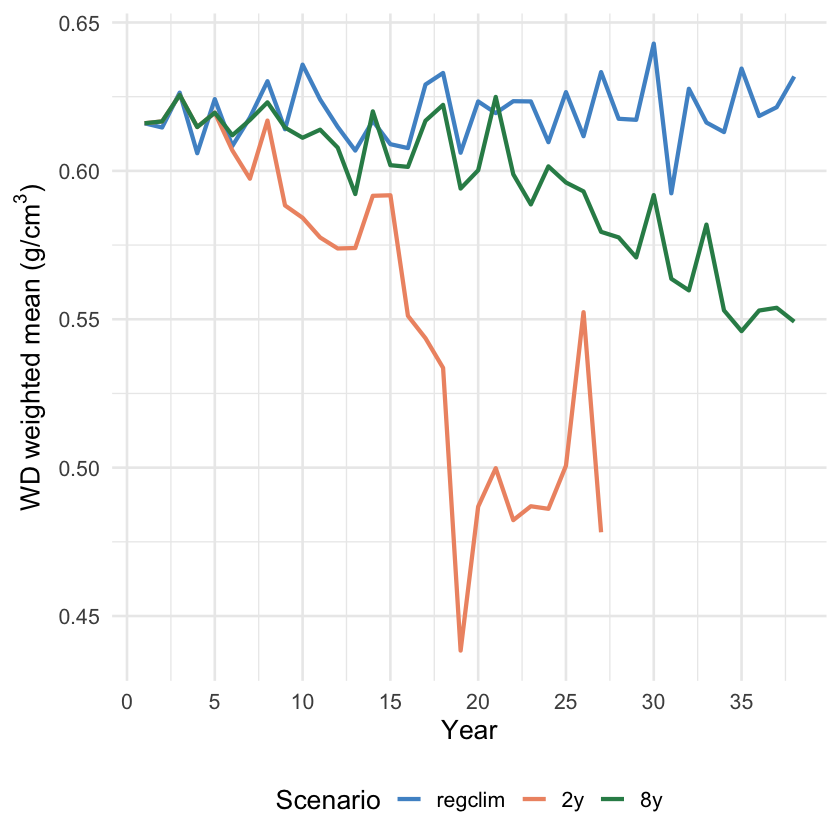

In [8]:

p_wd <- ggplot(wd_means, aes(x = run_year, y = weighted_mean_wd, color = Source)) + # nolint
  geom_line(linewidth = 1.2, na.rm = TRUE) + # nolint
  scale_color_manual(values = cols) + # nolint
  scale_x_continuous(breaks = seq(0, max(wd_means$run_year, na.rm = TRUE), by = 5)) + # nolint
  labs(x = "Year", y = expression("WD weighted mean (g/cm"^3*")"), color = "Scenario") + # nolint
  theme_minimal(base_size = 16) + theme(legend.position = "bottom")
p_wd



## TRAIT 2 — Specific Leaf Area

Compute weighted mean (*1000 is to change the unit to m2/kg)

In [9]:
sla_means <- df %>%
  group_by(Source, YEAR) %>%
  summarise(
    sum_OC = sum(OC, na.rm = TRUE),
    weighted_mean_sla = ifelse(
      is.finite(sum_OC) & sum_OC > 0,
      sum(sla_random * OC * 1000, na.rm = TRUE) / sum_OC,
      NA_real_
    ),
    .groups = "drop"
  ) %>%
  left_join(year_map, by = c("Source", "YEAR")) %>%
  arrange(Source, run_year)

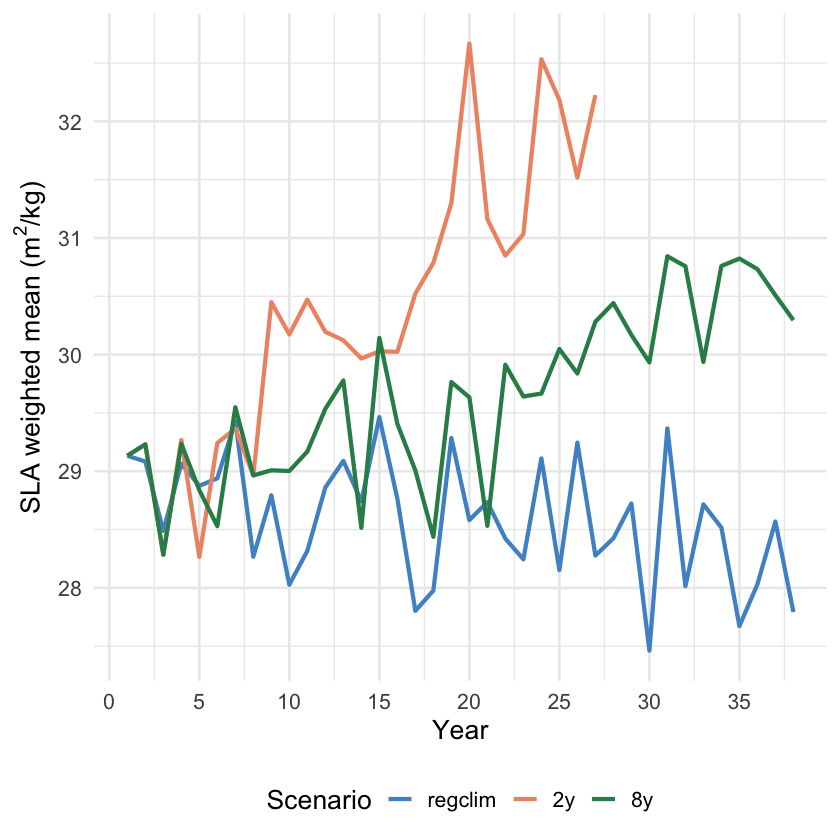

In [10]:
p_sla <- ggplot(sla_means,
                aes(x = run_year, y = weighted_mean_sla, color = Source)) +
  geom_line(linewidth = 1.2, na.rm = TRUE) +
  scale_color_manual(values = cols) +
  scale_x_continuous(breaks = seq(0, max(wd_means$run_year, na.rm = TRUE), by = 5)) + # nolint
  labs(x = "Year", y = expression("SLA weighted mean (m"^"2"*"/kg)"), color = "Scenario") + # nolint
  theme_minimal(base_size = 16) + theme(legend.position = "bottom")
p_sla


## TRAIT 3 — g1

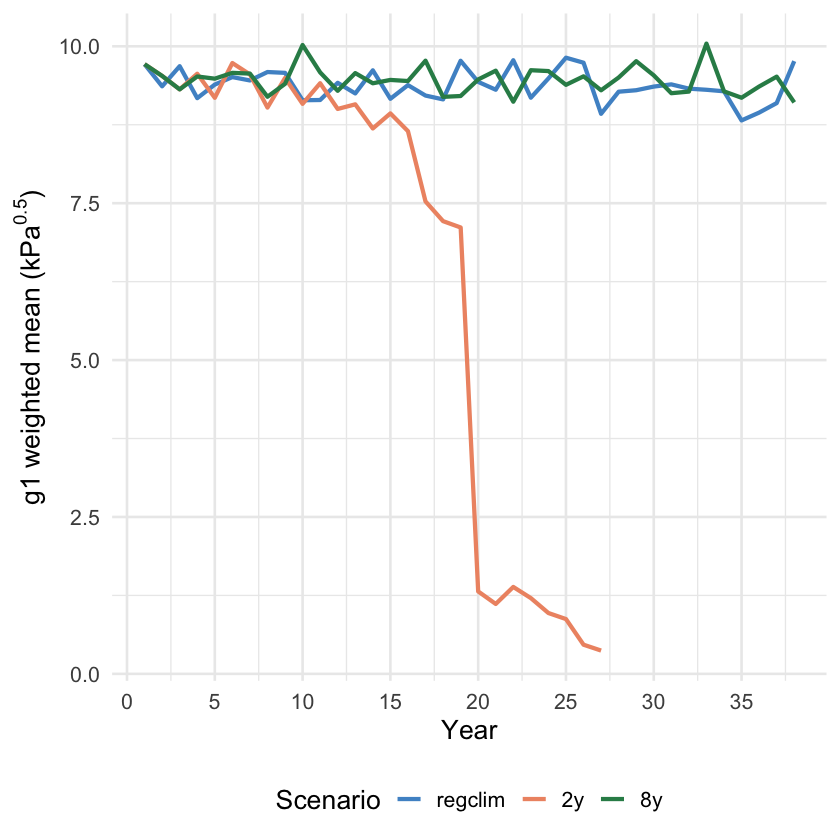

In [12]:
g1_means <- df %>%
  group_by(Source, YEAR) %>%
  summarise(
    sum_OC = sum(OC, na.rm = TRUE),
    weighted_mean_g1 = ifelse(
      is.finite(sum_OC) & sum_OC > 0,
      sum(g1 * OC, na.rm = TRUE) / sum_OC,
      NA_real_
    ),
    .groups = "drop"
  ) %>%
  left_join(year_map, by = c("Source", "YEAR")) %>%
  arrange(Source, run_year)

p_g1 <- ggplot(g1_means, aes(x = run_year, y = weighted_mean_g1, color = Source)) +
  geom_line(linewidth = 1.2, na.rm = TRUE) +
  scale_color_manual(values = cols) +
  scale_x_continuous(breaks = seq(0, max(wd_means$run_year, na.rm = TRUE), by = 5)) +
  labs(x = "Year", y = expression("g1 weighted mean (kPa"^{0.5}*")"), color = "Scenario") +
  theme_minimal(base_size = 16) + theme(legend.position = "bottom")
p_g1


# AMPLITUDE TEMPORAL SERIES

Here the amplitude is not weighted once it is only the range of values that exist.

Even if a PLS occupies only 0.1% of the gridcell, it still defines the min and max value


### a) Non normalized

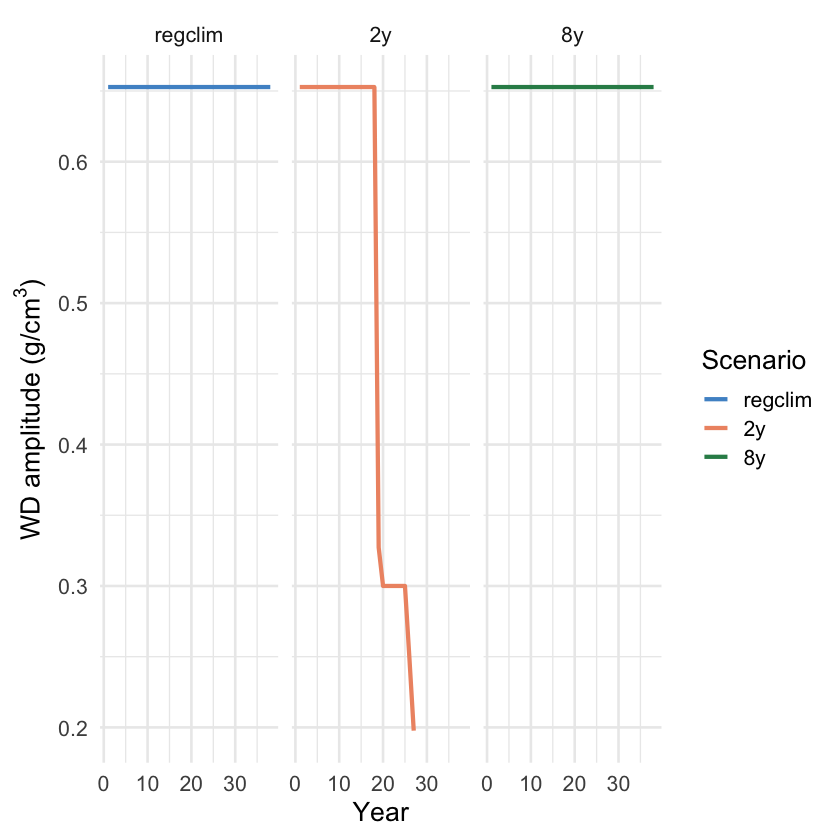

In [18]:
# Compute WD amplitude per scenario-year (no weights)
wd_amp <- df %>%
  filter(OC > 0) %>%   # only alive PLS
  group_by(Source, YEAR) %>%
  summarise(
    wd_min = min(wd_random, na.rm = TRUE),
    wd_max = max(wd_random, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(wd_amp = wd_max - wd_min) %>%
  left_join(year_map, by = c("Source", "YEAR")) %>%
  arrange(Source, run_year)

# Plot
p_wd_amp<-ggplot(wd_amp, aes(x = run_year, y = wd_amp, color = Source)) +
  geom_line(linewidth = 1.2) +
  scale_color_manual(values = cols) +
  labs(x = "Year", y = expression("WD amplitude (g/cm"^3*")"),
       color = "Scenario") +
  theme_minimal(base_size = 16) +
  facet_wrap(~Source, scales = "fixed")

p_wd_amp 

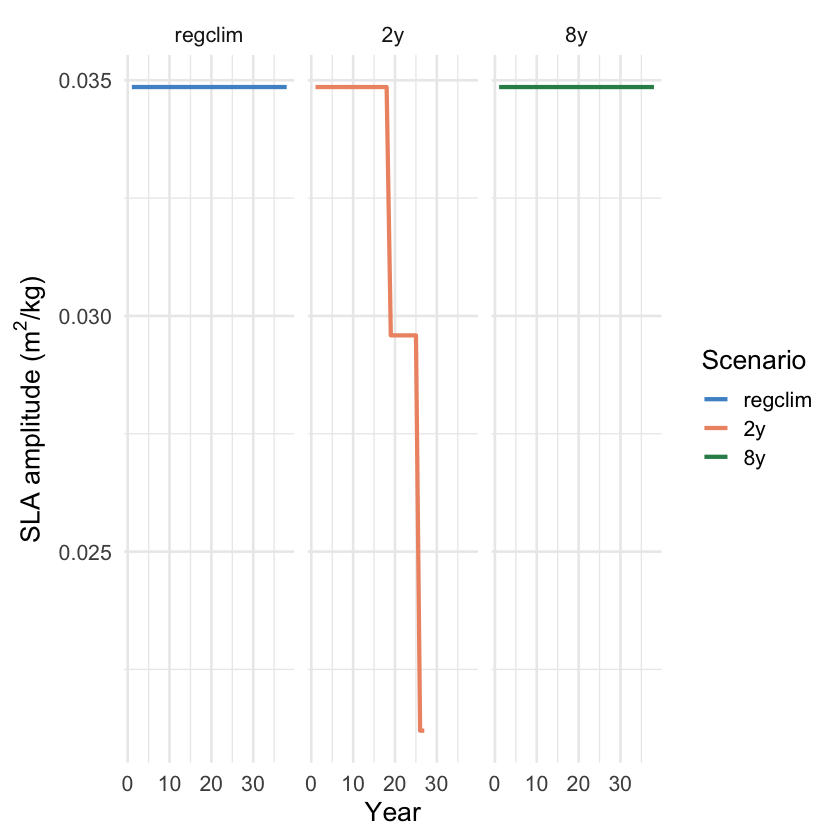

In [36]:
# Compute sla amplitude per scenario-year (no weights)
sla_amp <- df %>%
  filter(OC > 0) %>%   # only alive PLS
  group_by(Source, YEAR) %>%
  summarise(
    sla_min = min(sla_random, na.rm = TRUE),
    sla_max = max(sla_random, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(sla_amp = sla_max - sla_min) %>%
  left_join(year_map, by = c("Source", "YEAR")) %>%
  arrange(Source, run_year)

# Plot
p_sla_amp<-ggplot(sla_amp, aes(x = run_year, y = sla_amp, color = Source)) +
  geom_line(linewidth = 1.2) +
  scale_color_manual(values = cols) +
  labs(x = "Year", y = expression("SLA amplitude (m"^"2"*"/kg)"),
       color = "Scenario") +
  theme_minimal(base_size = 16) +
  facet_wrap(~Source, scales = "fixed")

p_sla_amp 

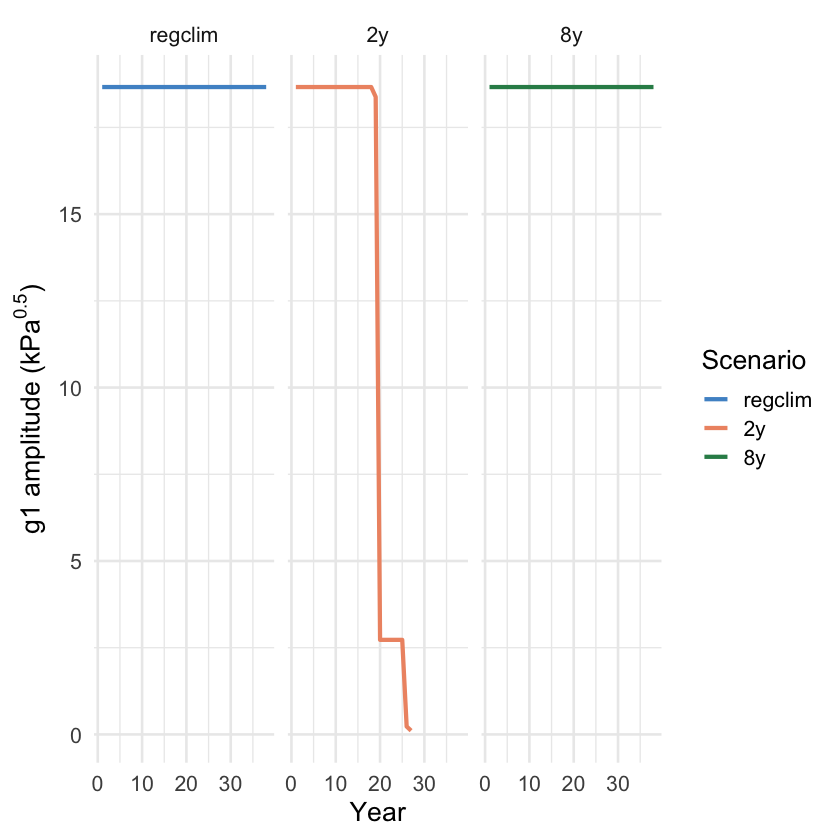

In [22]:
# Compute g1 amplitude per scenario-year (no weights)
g1_amp <- df %>%
  filter(OC > 0) %>%   # only alive PLS
  group_by(Source, YEAR) %>%
  summarise(
    g1_min = min(g1, na.rm = TRUE),
    g1_max = max(g1, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(g1_amp = g1_max - g1_min) %>%
  left_join(year_map, by = c("Source", "YEAR")) %>%
  arrange(Source, run_year)

# Plot
p_g1_amp<-ggplot(g1_amp, aes(x = run_year, y = g1_amp, color = Source)) +
  geom_line(linewidth = 1.2) +
  scale_color_manual(values = cols) +
  labs(x = "Year", y = expression("g1 amplitude (kPa"^{0.5}*")"),
  color = "Scenario") +
  theme_minimal(base_size = 16) +
  facet_wrap(~Source, scales = "fixed")

p_g1_amp 

### b) Normalized

Prepare normalization

min/max for 0–1 rescaling

In [24]:
wd_min <- min(df$wd_random, na.rm = TRUE)
wd_max <- max(df$wd_random, na.rm = TRUE)
sla_min <- min(df$sla_random, na.rm = TRUE)
sla_max <- max(df$sla_random, na.rm = TRUE)
g1_min <- min(df$g1, na.rm = TRUE)
g1_max <- max(df$g1, na.rm = TRUE)

Include in the original table

In [32]:
df <- df %>%
  dplyr::mutate(
    wd_01  = (wd_random  - wd_min)  / (wd_max  - wd_min),
    sla_01 = (sla_random - sla_min) / (sla_max - sla_min),
    g1_01  = (g1         - g1_min)  / (g1_max  - g1_min)
  )


In [37]:
# Attach run_year to df (per Source)
df <- df %>%
  left_join(year_map, by = c("Source", "YEAR"))

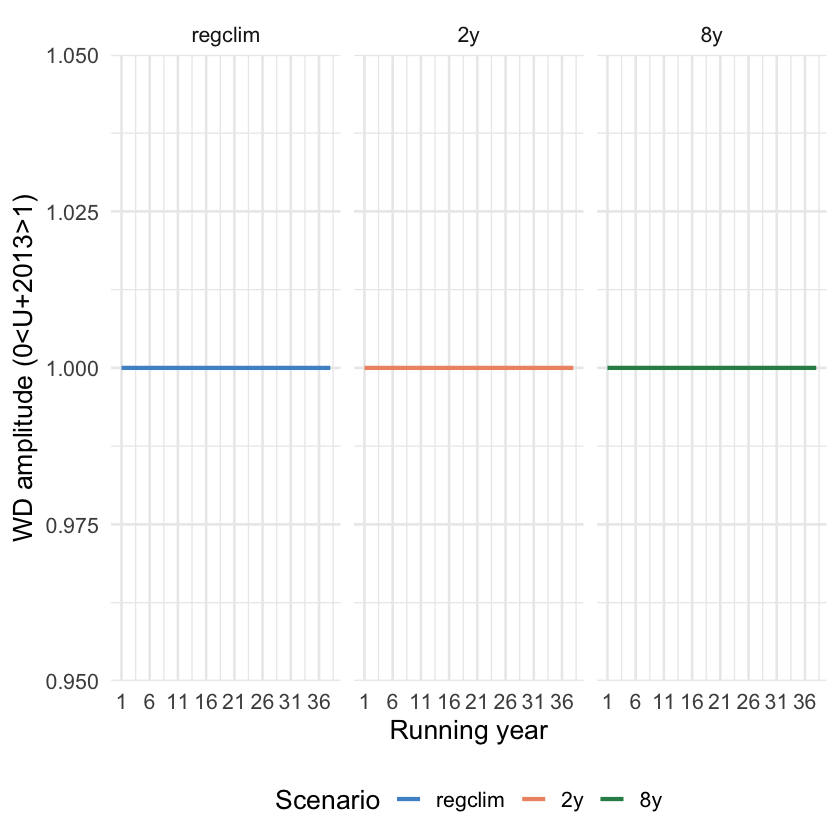

In [39]:
wd_amp_01 <- df %>%
  group_by(Source, YEAR, run_year) %>%
  summarise(
    wd_min_01 = min(wd_01, na.rm = TRUE),
    wd_max_01 = max(wd_01, na.rm = TRUE),
    wd_amp_01 = wd_max_01 - wd_min_01,
    .groups = "drop"
  ) %>%
  arrange(Source, run_year)

p_wd_amp_01 <- ggplot(wd_amp_01, aes(run_year, wd_amp_01, color = Source)) +
  geom_line(linewidth = 1.2, na.rm = TRUE) +
  scale_color_manual(values = cols) +
  scale_x_continuous(breaks = seq(1, max(wd_amp_01$run_year, na.rm = TRUE), by = 5)) +
  labs(x = "Running year", y = "WD amplitude (0–1)", color = "Scenario") +
  theme_minimal(base_size = 16) + theme(legend.position = "bottom")+
  facet_wrap(~Source, scales = "fixed")
p_wd_amp_01


Another option for normalization is trough mean/sd and z-score

In [34]:

wd_mu <- mean(df$wd_random, na.rm = TRUE)
wd_sd <- sd(df$wd_random, na.rm = TRUE)
sla_mu <- mean(df$sla_random, na.rm = TRUE)
sla_sd <- sd(df$sla_random, na.rm = TRUE)
g1_mu <- mean(df$g1, na.rm = TRUE)
g1_sd <- sd(df$g1, na.rm = TRUE)

df <- df %>%
  dplyr::mutate(
    wd_z  = (wd_random  - wd_mu)  / wd_sd,
    sla_z = (sla_random - sla_mu) / sla_sd,
    g1_z  = (g1         - g1_mu)  / g1_sd
  )